# 🔍📊🧪 **Univariate Analysis (Categorical Variables)**

In [1]:
# 📦 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import fetch_openml

In [2]:
# 🔽 Fetch adult dataset
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
# df = df.dropna(axis=0)
print(df.shape) 

(48842, 15)


In [3]:
# 🔍 Show categorical columns
cat_cols = df.select_dtypes(include='category').columns.tolist()
print("Categorical columns:", cat_cols)
df = df.dropna(axis=0)
df.head()

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'class']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


🔎 Performing bivariate analysis between:
 └── Column 'sex' (Type: categorical)
 └── Column 'race' (Type: categorical)

🧪 Chi2 Statistic: 619.70 (P-Value: 0.0000)
🧪 Cramér's V: 0.12
   └── ⚠️ Significant association with moderate effect.


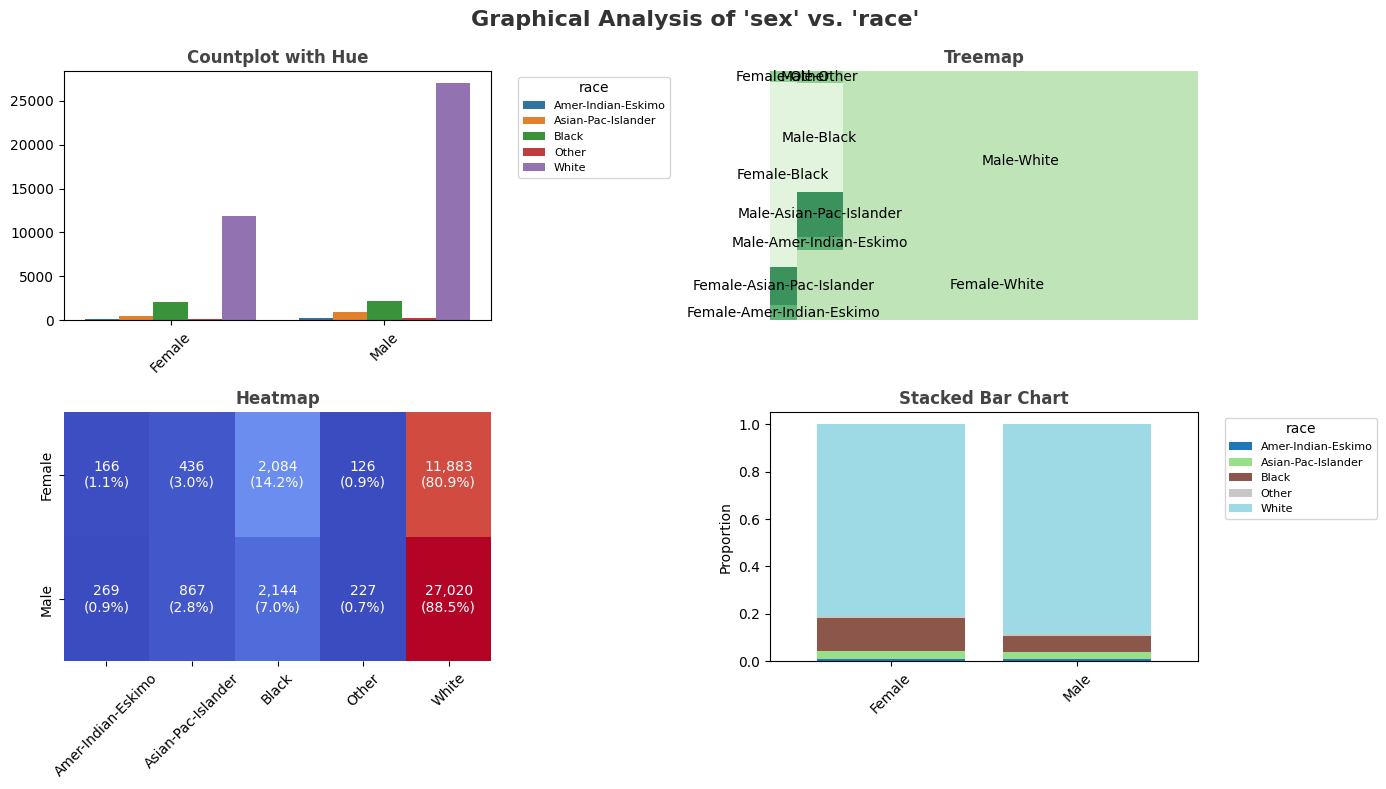

In [4]:
feature1 = "sex"
feature2 = "race"

from perform_bivariate_analysis import perform_bivariate_analysis
perform_bivariate_analysis(df, feature1, feature2)

---
---
# **🧪 Statistical Analysis**

- Summary numbers and tests (e.g., count, mode, chi-square goodness-of-fit).

---
## **└─ Data Integrity Checks**

| Check                | Why It Matters                           |
| -------------------- | ---------------------------------------- |
| Column exists        | Avoid silent failure                     |
| Data type            | Impacts what analyses/visuals you can do |
| Missing values       | Influences treatment strategy            |
| Constant feature     | Zero variance = no predictive power      |
| Suspicious strings   | Dirty categorical data                   |
| Out-of-domain values | E.g., negative age or zero salary        |


🔎 Performing univariate analysis:
 └── Column 'relationship' (Type: categorical)

📘 Data Type: category
💎 Unique Non-NA Values: 6
📊 Frequency Table:


,Count,Percentage (%)
Husband,"18,666",41.28
Not-in-family,"11,702",25.88
Own-child,"6,626",14.65
Unmarried,"4,788",10.59
Wife,"2,091",4.62
Other-relative,"1,349",2.98


✅ No rows with missing values found.


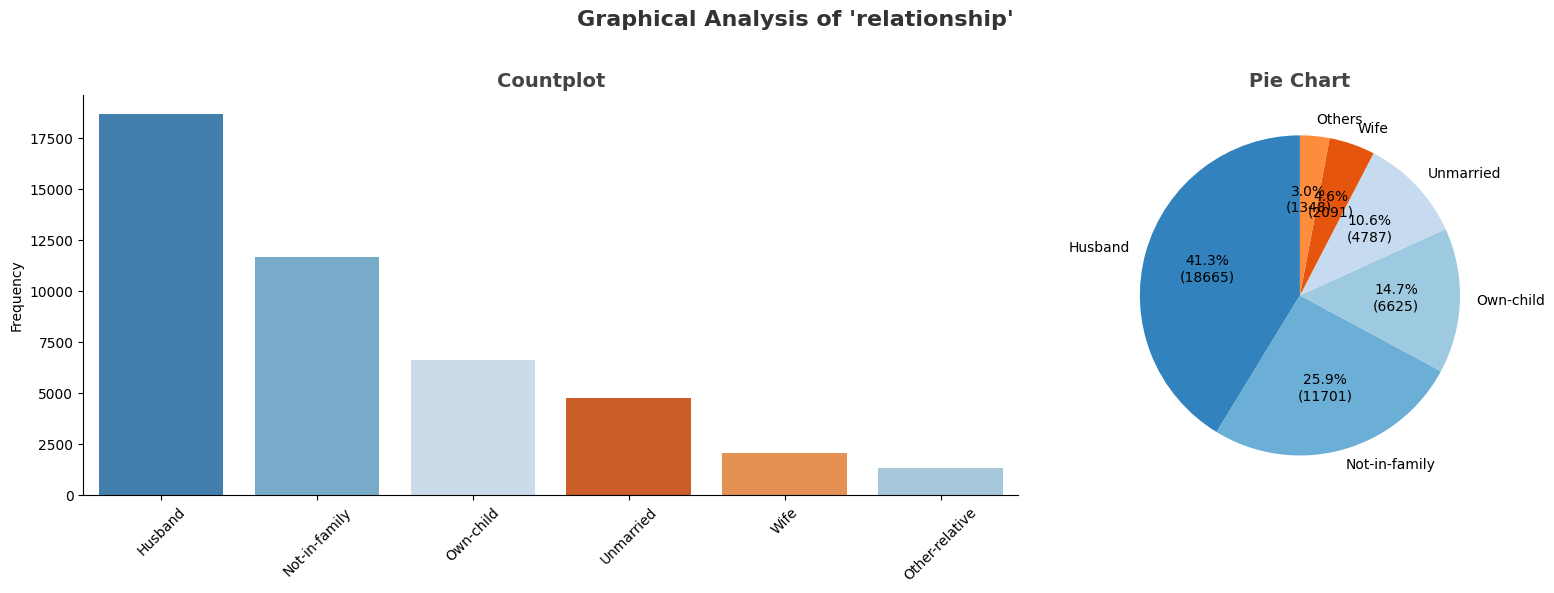

In [5]:
feature = "relationship"

from perform_univariate_analysis import perform_univariate_analysis
perform_univariate_analysis(df, feature)

🔎 Performing univariate analysis:
 └── Column 'education-num' (Type: numerical)

📘 Data Type: int64
💎 Unique Non-NA Values: 16
📊 Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
education-num,45222.00,10.12,2.55,1.00,9.00,10.00,13.00,16.00


📈 Distribution Shape:
   └── Skewness: -0.31 
   └── Kurtosis (excess): 0.64 

🔍 Outlier Detection: Z-Score Method
   └── ⚠️ 294 outliers found (0.65% of rows)
   └── Outliers summary:


,count,mean,std,min,25%,50%,75%,max
education-num,294.00,1.76,0.43,1.00,2.00,2.00,2.00,2.00


✅ No rows with missing values found.


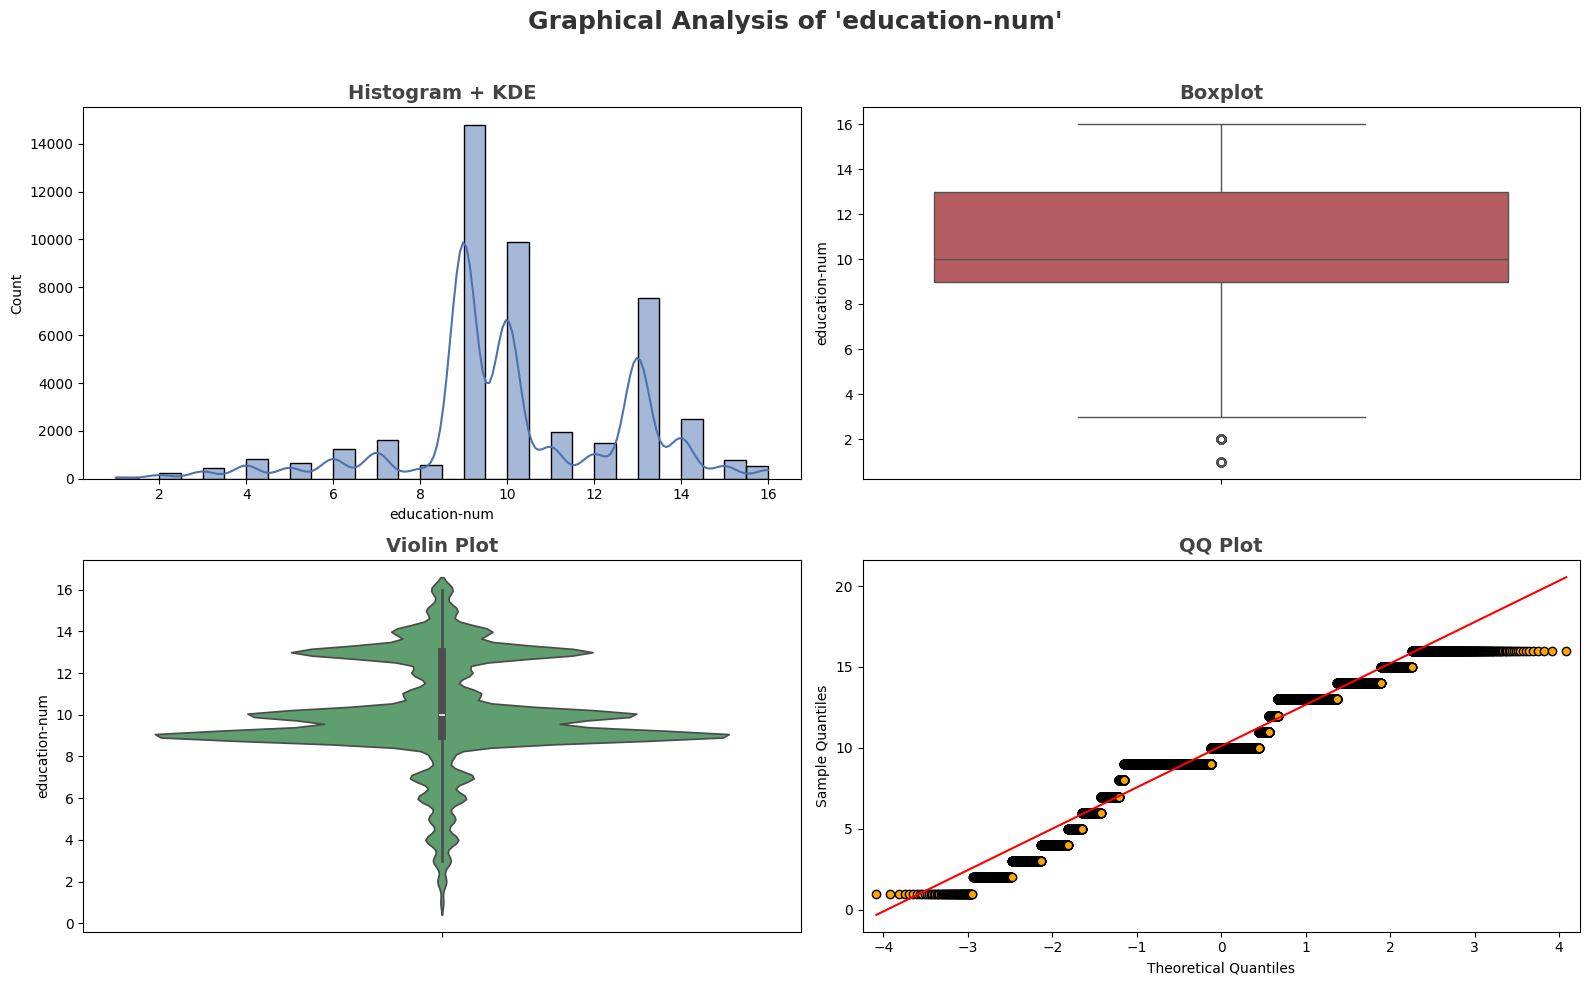

In [6]:
feature = "education-num"

from perform_univariate_analysis import perform_univariate_analysis
perform_univariate_analysis(df, feature)

---
---
# **📊 Graphical Analysis**

- Plots and charts that help visualize distributions (e.g., bar chart, pie chart).

---
## **└─ Bar Plot**

- Shows how many times each category appears, using vertical bars.

- **🧠 When to use**: When you want to compare frequency of each category clearly.

- **⚠️ Avoid when**: Too many categories or long text labels.

- **✅ Pros**: Easy to read, supports sorting, can add count labels.

- **❌ Cons**: Can be cluttered with many categories.

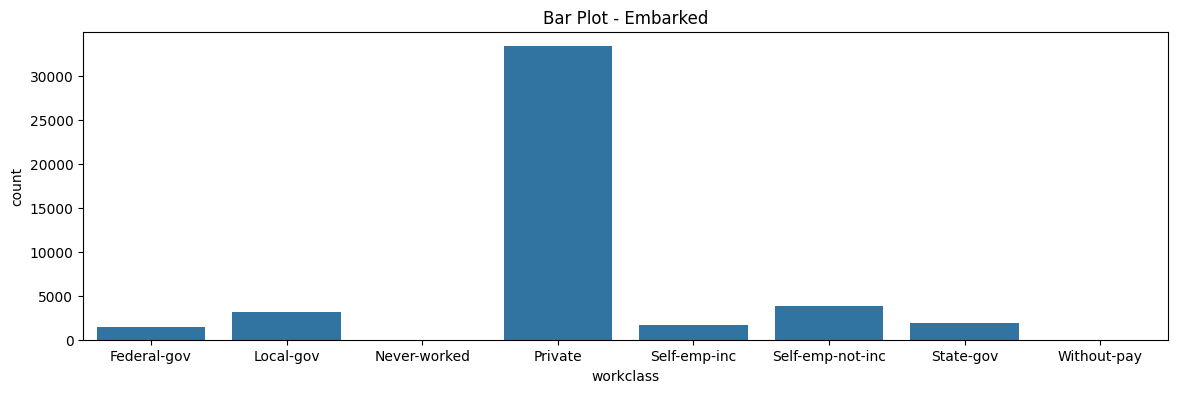

In [10]:
feature = "workclass"

plt.figure(figsize=(14, 4))
sns.countplot(x=feature, data=df)
plt.title('Bar Plot - Embarked')
plt.show()

---
## **└─ Pie Chart**

- Each slice shows a category’s proportion of the total.

- **🧠 When to use**: When you want to show percentage of total for up to 5 categories.

- **⚠️ Avoid when**: Comparing actual values or many categories.

- **✅ Pros**: Simple and familiar, good for showing part-to-whole visually.

- **❌ Cons**: Hard to compare slices of similar size.

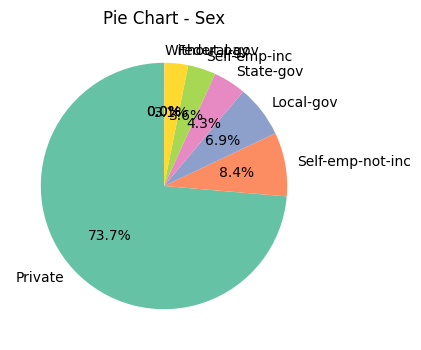

In [11]:
feature = "workclass"

plt.figure(figsize=(4, 4))
df[feature].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Set2')
plt.title('Pie Chart - Sex')
plt.ylabel('')
plt.show()

---
## **└─ Donut Chart**

- A pie chart with a hole in the middle — more modern look.

- **🧠 When to use**: Same as pie chart, but for presentations or aesthetics.

- **⚠️ Avoid when**: Precision is needed.

- **✅ Pros**: Looks cleaner, allows placing text in center.

- **❌ Cons**: Same readability issues as pie chart.

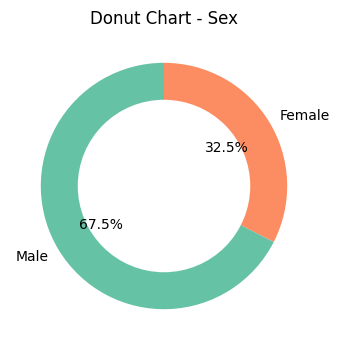

In [12]:
counts = df['sex'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Donut Chart - Sex')
plt.show()